In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("cleaned_churn.csv")

# Drop the charge columns (they duplicate the minutes columns)
df = df.drop(columns=["total_day_charge", "total_eve_charge",
                      "total_night_charge", "total_intl_charge"])

# Turn the State text column into 0/1 columns (one per state)
df = pd.get_dummies(df, columns=["state"], drop_first=True)

X = df.drop(columns=["churn"])
y = df["churn"]
print(X.shape)
print(y.value_counts(normalize=True))

(667, 64)
churn
0    0.857571
1    0.142429
Name: proportion, dtype: float64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), False),
    "Random Forest": (RandomForestClassifier(random_state=42), False),
}

results = []
for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.866,0.556,0.263,0.357
1,Decision Tree,0.903,0.650,0.684,0.667
2,Random Forest,0.896,1.000,0.263,0.417


In [4]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best settings:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Best settings: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best cross-validated F1: 0.581


In [5]:
best = grid.best_estimator_
pred = best.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, pred), 3))
print("F1       :", round(f1_score(y_test, pred), 3))

Accuracy : 0.925
Precision: 0.714
Recall   : 0.789
F1       : 0.75


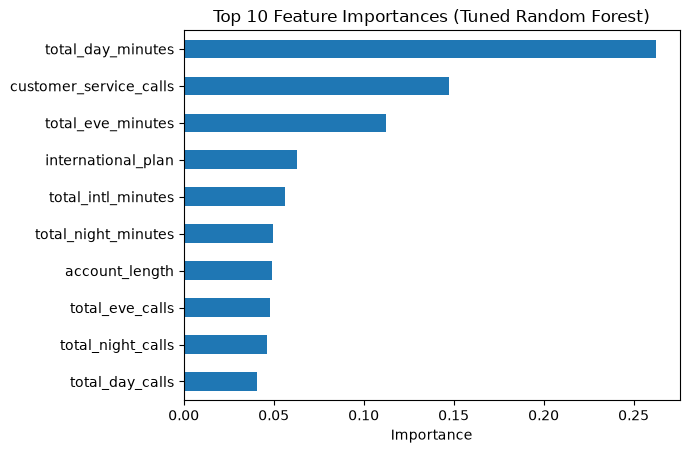

In [6]:
importances = pd.Series(best.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(10).plot(kind="barh")
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Classification summary: Three models were trained to predict churn (about 14% of customers). Accuracy was 87-90% for all three but is misleading because most customers stay, so models were compared on precision, recall and F1. The Decision Tree gave the best balance among the untuned models (F1 0.667). A grid search over the Random Forest, scored on F1 with 5-fold cross-validation, selected class_weight='balanced', min_samples_leaf=5 and 100 trees. The tuned model reached accuracy 0.925, precision 0.714, recall 0.789 and F1 0.750 on the test set (cross-validated F1 0.581). Class balancing was the key improvement, as it raised recall from 0.26 to 0.79. The most important features were total day minutes, customer service calls, total evening minutes and the international plan. The test set has only about 19 churners, so these metrics are noisy and should be treated as indicative.